In [28]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

%matplotlib inline

In [29]:
df = pd.read_excel("EastWestAirliness.xlsx")

In [30]:
df.head()

,ID,Balance,Qual_miles,cc1_miles,cc2_miles,cc3_miles,Bonus_miles,Bonus_trans,Flight_miles_12mo,Flight_trans_12,Days_since_enroll,Award?
0,1,28143,0,1,1,1,174,1,0,0,7000,0
1,2,19244,0,1,1,1,215,2,0,0,6968,0
2,3,41354,0,1,1,1,4123,4,0,0,7034,0
3,4,14776,0,1,1,1,500,1,0,0,6952,0
4,5,97752,0,4,1,1,43300,26,2077,4,6935,1


In [31]:
df.shape

(3999, 12)

In [32]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3999 entries, 0 to 3998
Data columns (total 12 columns):
 #   Column             Non-Null Count  Dtype
---  ------             --------------  -----
 0   ID                 3999 non-null   int64
 1   Balance            3999 non-null   int64
 2   Qual_miles         3999 non-null   int64
 3   cc1_miles          3999 non-null   int64
 4   cc2_miles          3999 non-null   int64
 5   cc3_miles          3999 non-null   int64
 6   Bonus_miles        3999 non-null   int64
 7   Bonus_trans        3999 non-null   int64
 8   Flight_miles_12mo  3999 non-null   int64
 9   Flight_trans_12    3999 non-null   int64
 10  Days_since_enroll  3999 non-null   int64
 11  Award?             3999 non-null   int64
dtypes: int64(12)
memory usage: 375.0 KB


In [33]:
df.describe()

,ID,Balance,Qual_miles,cc1_miles,cc2_miles,cc3_miles,Bonus_miles,Bonus_trans,Flight_miles_12mo,Flight_trans_12,Days_since_enroll,Award?
count,3999.000000,3.999000e+03,3999.000000,3999.000000,3999.000000,3999.000000,3999.000000,3999.00000,3999.000000,3999.000000,3999.00000,3999.000000
mean,2014.819455,7.360133e+04,144.114529,2.059515,1.014504,1.012253,17144.846212,11.60190,460.055764,1.373593,4118.55939,0.370343
std,1160.764358,1.007757e+05,773.663804,1.376919,0.147650,0.195241,24150.967826,9.60381,1400.209171,3.793172,2065.13454,0.482957
min,1.000000,0.000000e+00,0.000000,1.000000,1.000000,1.000000,0.000000,0.00000,0.000000,0.000000,2.00000,0.000000
25%,1010.500000,1.852750e+04,0.000000,1.000000,1.000000,1.000000,1250.000000,3.00000,0.000000,0.000000,2330.00000,0.000000
50%,2016.000000,4.309700e+04,0.000000,1.000000,1.000000,1.000000,7171.000000,12.00000,0.000000,0.000000,4096.00000,0.000000
75%,3020.500000,9.240400e+04,0.000000,3.000000,1.000000,1.000000,23800.500000,17.00000,311.000000,1.000000,5790.50000,1.000000
max,4021.000000,1.704838e+06,11148.000000,5.000000,3.000000,5.000000,263685.000000,86.00000,30817.000000,53.000000,8296.00000,1.000000


In [34]:
df.isnull().sum()

,0
ID,0
Balance,0
Qual_miles,0
cc1_miles,0
cc2_miles,0
cc3_miles,0
Bonus_miles,0
Bonus_trans,0
Flight_miles_12mo,0
Flight_trans_12,0


In [35]:
df.duplicated().sum()

np.int64(0)

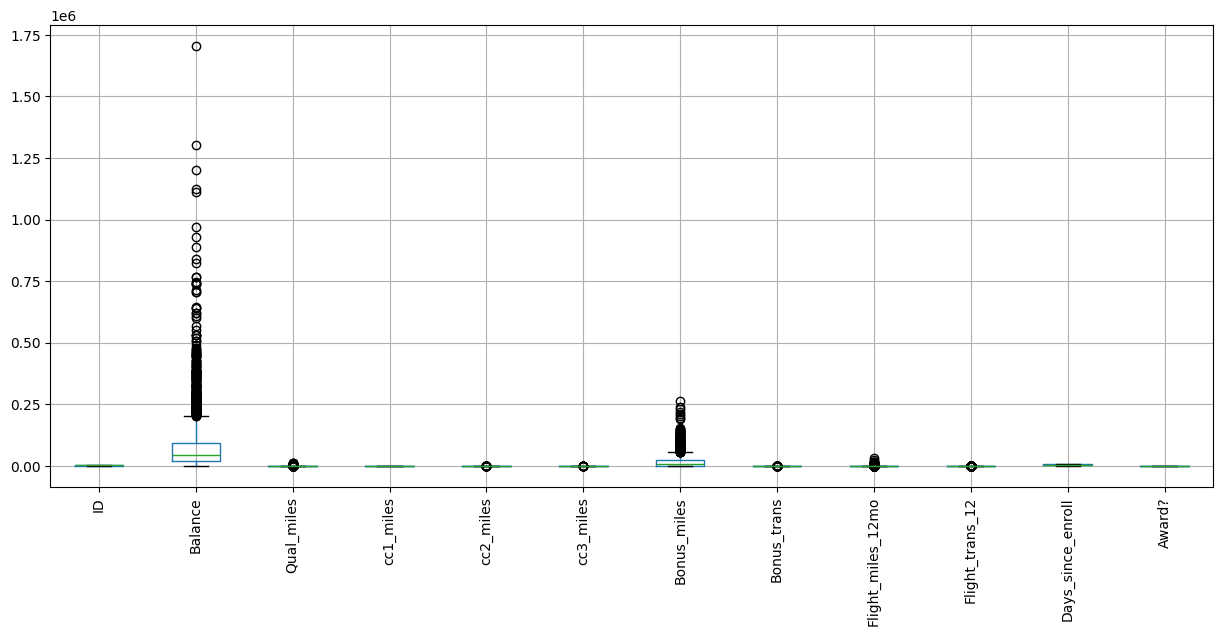

In [36]:
plt.figure(figsize=(15,6))

df.boxplot()

plt.xticks(rotation=90)

plt.show()

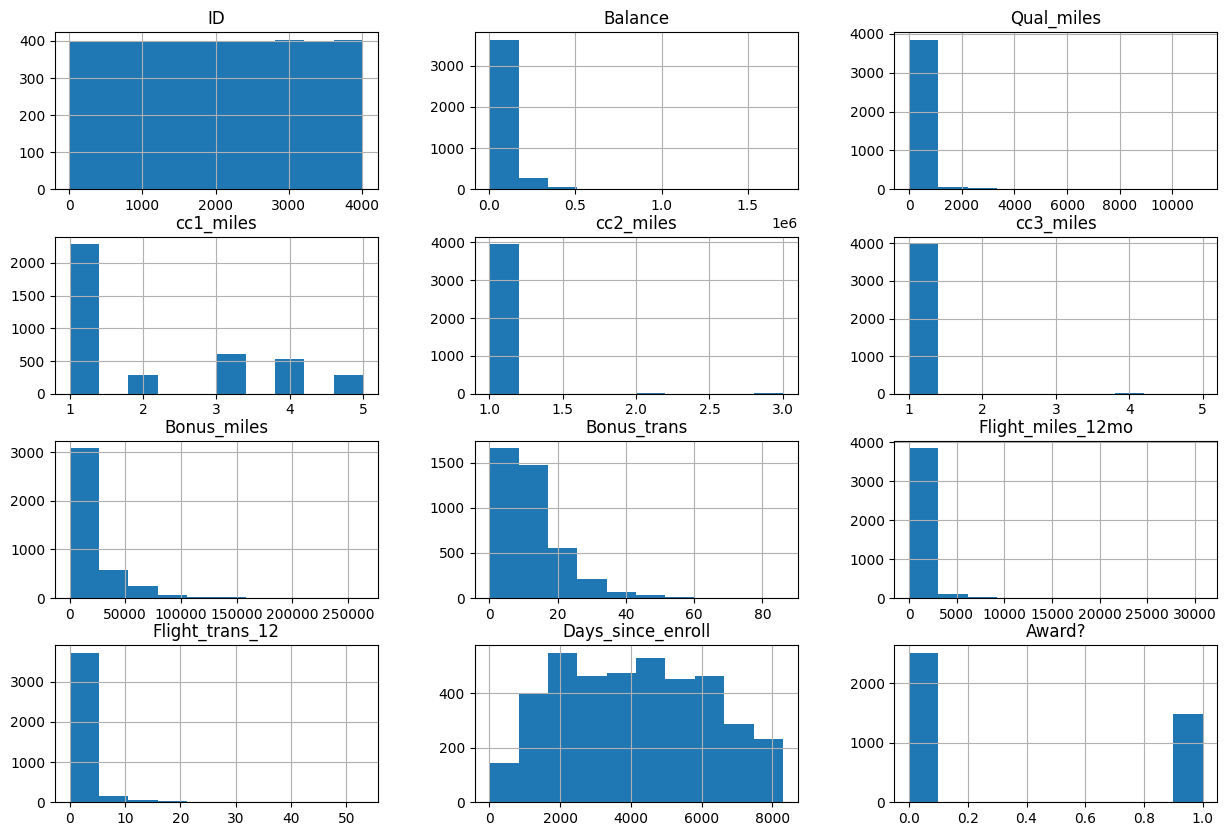

In [37]:
df.hist(figsize=(15,10))

plt.show()

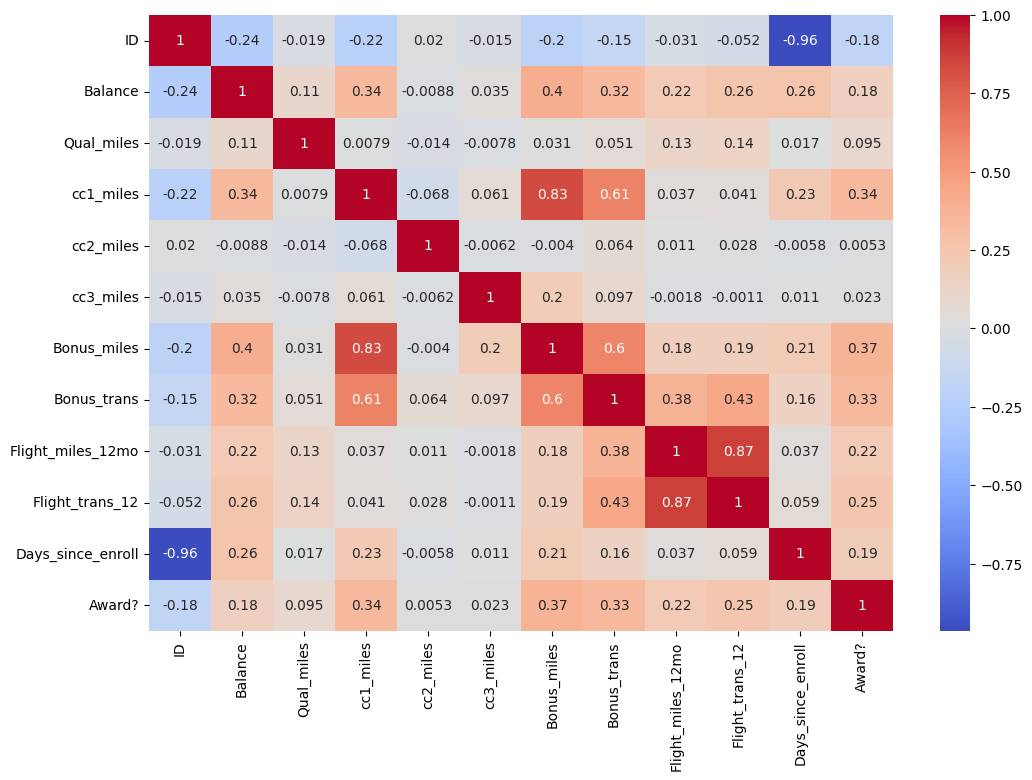

In [38]:
plt.figure(figsize=(12,8))

sns.heatmap(
    df.corr(),
    annot=True,
    cmap="coolwarm"
)

plt.show()

In [40]:
Q1 = df.quantile(0.25)
Q3 = df.quantile(0.75)

IQR = Q3 - Q1

df_outlier = df[~((df < (Q1 - 1.5 * IQR)) |
                  (df > (Q3 + 1.5 * IQR))).any(axis=1)]

df_outlier.shape

(2875, 12)

In [41]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_scaled = scaler.fit_transform(df_outlier)

X_scaled.shape

(2875, 12)

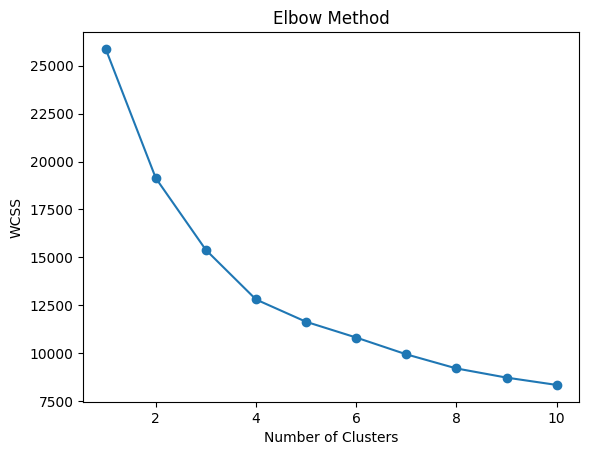

In [42]:
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

wcss = []

for i in range(1, 11):

    kmeans = KMeans(
        n_clusters=i,
        random_state=42,
        n_init=10
    )

    kmeans.fit(X_scaled)

    wcss.append(kmeans.inertia_)

plt.plot(range(1,11), wcss, marker='o')

plt.xlabel("Number of Clusters")

plt.ylabel("WCSS")

plt.title("Elbow Method")

plt.show()

In [43]:
kmeans = KMeans(
    n_clusters=4,
    random_state=42,
    n_init=10
)

kmeans_clusters = kmeans.fit_predict(X_scaled)

kmeans_clusters

array([2, 2, 2, ..., 1, 3, 0], dtype=int32)

In [44]:
pd.Series(kmeans_clusters).value_counts()

,count
0,1000
2,786
1,744
3,345


In [46]:
from sklearn.metrics import silhouette_score

kmeans_silhouette = silhouette_score(
    X_scaled,
    kmeans_clusters
)

print("K-Means Silhouette Score :", kmeans_silhouette)

K-Means Silhouette Score : 0.2618146384661026


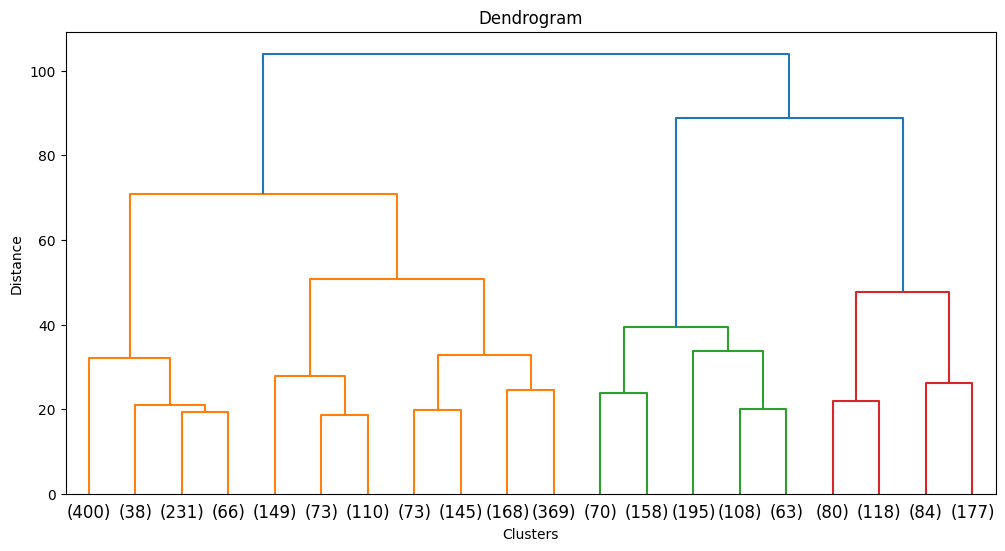

In [47]:
from scipy.cluster.hierarchy import dendrogram, linkage
import matplotlib.pyplot as plt

linked = linkage(
    X_scaled,
    method='ward'
)

plt.figure(figsize=(12,6))

dendrogram(
    linked,
    truncate_mode='lastp',
    p=20
)

plt.title("Dendrogram")

plt.xlabel("Clusters")

plt.ylabel("Distance")

plt.show()

In [48]:
from sklearn.cluster import AgglomerativeClustering

hc = AgglomerativeClustering(
    n_clusters=3
)

hc_clusters = hc.fit_predict(X_scaled)

hc_clusters

array([0, 0, 0, ..., 2, 1, 0])

In [49]:
pd.Series(hc_clusters).value_counts()

,count
0,1822
2,594
1,459


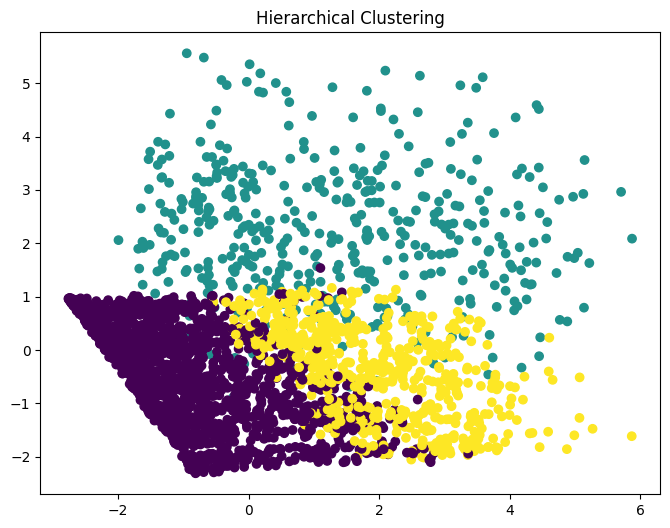

In [50]:
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt

pca = PCA(n_components=2)

X_pca = pca.fit_transform(X_scaled)

plt.figure(figsize=(8,6))

plt.scatter(
    X_pca[:,0],
    X_pca[:,1],
    c=hc_clusters,
    cmap="viridis"
)

plt.title("Hierarchical Clustering")

plt.show()

In [51]:
from sklearn.metrics import silhouette_score

hc_silhouette = silhouette_score(
    X_scaled,
    hc_clusters
)

print("Hierarchical Silhouette Score :",
      hc_silhouette)

Hierarchical Silhouette Score : 0.27936255076255034


In [52]:
pd.Series(hc_clusters).value_counts()

hc_silhouette

np.float64(0.27936255076255034)

In [53]:
from sklearn.cluster import DBSCAN

dbscan = DBSCAN(
    eps=0.8,
    min_samples=10
)

dbscan_clusters = dbscan.fit_predict(X_scaled)

dbscan_clusters

array([ 0,  0,  0, ..., -1, -1,  0])

In [54]:
pd.Series(dbscan_clusters).value_counts()

,count
0,1217
-1,971
2,200
1,158
3,111
5,85
6,49
4,41
8,17
7,13


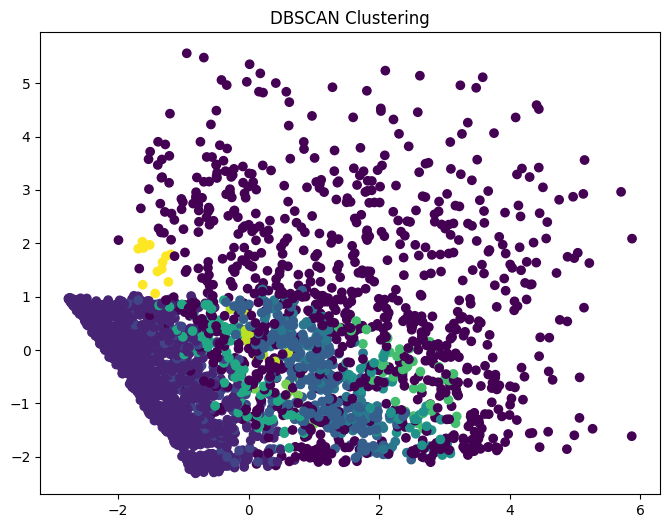

In [55]:
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt

plt.figure(figsize=(8,6))

plt.scatter(
    X_pca[:,0],
    X_pca[:,1],
    c=dbscan_clusters,
    cmap="viridis"
)

plt.title("DBSCAN Clustering")

plt.show()

In [56]:
from sklearn.metrics import silhouette_score

dbscan_silhouette = silhouette_score(
    X_scaled,
    dbscan_clusters
)

print("DBSCAN Silhouette Score :",
      dbscan_silhouette)

DBSCAN Silhouette Score : -0.04868458569798797


In [57]:
pd.Series(dbscan_clusters).value_counts()

dbscan_silhouette

np.float64(-0.04868458569798797)

**Cluster Analysis and Interpretation**

**K-Means:**

* K-Means divided the customers into 4 clusters.
* Some customers have higher balance and bonus miles, while others have lower values.

**Hierarchical Clustering:**

* Hierarchical clustering divided the customers into 3 clusters.
* It gave the highest silhouette score among all the methods used.

**DBSCAN:**

* DBSCAN identified some groups of customers and also treated some records as noise.
* Its silhouette score was lower compared to K-Means and Hierarchical Clustering.

**Overall:**

* The dataset contains different groups of airline customers based on their travel and reward information.
* Hierarchical Clustering performed better than K-Means and DBSCAN for this dataset.
